### Classical Machine Learning
### Load and Flatten the Data
Classical ML models can't read a 2D MFCC image directly. so we need to flatten the 40 x 32 MFCC matrix into a single 1,280-length vector.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
base_path    = '/content/drive/MyDrive/speech_commands_project'
log_path     = '/content/drive/MyDrive/speech_commands_project/logs'
results_path = '/content/drive/MyDrive/speech_commands_project/results'
processed_path = '/content/drive/MyDrive/speech_commands_project/data/processed'

os.makedirs(log_path,     exist_ok=True)
os.makedirs(results_path, exist_ok=True)

Mounted at /content/drive


In [2]:
import numpy as np
import os
import time
import sys
import pickle
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)

CLASS_NAMES = ['tree', 'three', 'two']

X_train = np.load(os.path.join(processed_path, 'X_train.npy'))
y_train = np.load(os.path.join(processed_path, 'y_train.npy'))
X_test  = np.load(os.path.join(processed_path, 'X_test.npy'))
y_test  = np.load(os.path.join(processed_path, 'y_test.npy'))

# Flatten 40x32 MFCC -> 1280-length vector
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

print(f"Train: {X_train_flat.shape}  Test: {X_test_flat.shape}")
print(f"Label mapping: 0={CLASS_NAMES[0]}, 1={CLASS_NAMES[1]}, 2={CLASS_NAMES[2]}")


Train: (7492, 1280)  Test: (937, 1280)
Label mapping: 0=tree, 1=three, 2=two


### **Train Random Forest**
##### Build multiple decision trees to classify the 1,280 features in your flattened MFCCs.


In [3]:
# n_estimators=100 is a good starting point for robustness
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

t0 = time.time()
rf_model.fit(X_train_flat, y_train)
rf_train_time_sec = round(time.time() - t0, 4)

rf_preds = rf_model.predict(X_test_flat)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy:    {rf_acc:.2%}")
print(f"Random Forest Train time:  {rf_train_time_sec:.4f} s")


Random Forest Accuracy:    78.76%
Random Forest Train time:  52.7330 s


## **Train SVM (The Geometric Comparison)**
##### Try to find the optimal hyperplane that separates "tree," "three," and "two" in the feature space.

In [4]:
# RBF kernel handles non-linear relationships in speech audio data
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)

t0 = time.time()
svm_model.fit(X_train_flat, y_train)
svm_train_time_sec = round(time.time() - t0, 4)

svm_preds = svm_model.predict(X_test_flat)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy:    {svm_acc:.2%}")
print(f"SVM Train time:  {svm_train_time_sec:.4f} s")

SVM Accuracy:    80.26%
SVM Train time:  235.6698 s


## **Classification Reports and Confusion Matrices**


--- Random_Forest Classification Report ---
              precision  recall  f1-score  support
tree               0.68    0.36      0.47   176.00
three              0.74    0.86      0.80   373.00
two                0.86    0.91      0.89   388.00
accuracy           0.79    0.79      0.79     0.79
macro avg          0.76    0.71      0.72   937.00
weighted avg       0.78    0.79      0.77   937.00
Saved to /content/drive/MyDrive/speech_commands_project/results/Random_Forest_classification_report.csv


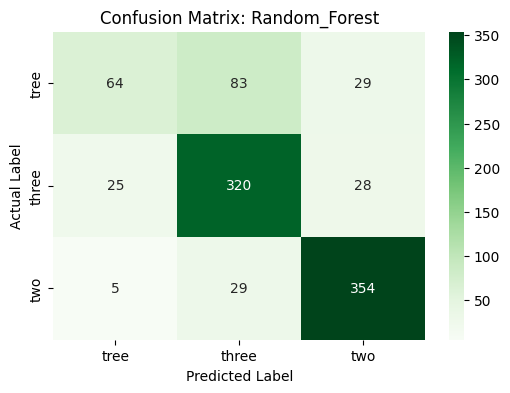

Saved to /content/drive/MyDrive/speech_commands_project/results/Random_Forest_confusion_matrix.png

--- SVM Classification Report ---
              precision  recall  f1-score  support
tree               0.68    0.51      0.58    176.0
three              0.80    0.83      0.81    373.0
two                0.85    0.91      0.88    388.0
accuracy           0.80    0.80      0.80      0.8
macro avg          0.77    0.75      0.76    937.0
weighted avg       0.80    0.80      0.80    937.0
Saved to /content/drive/MyDrive/speech_commands_project/results/SVM_classification_report.csv


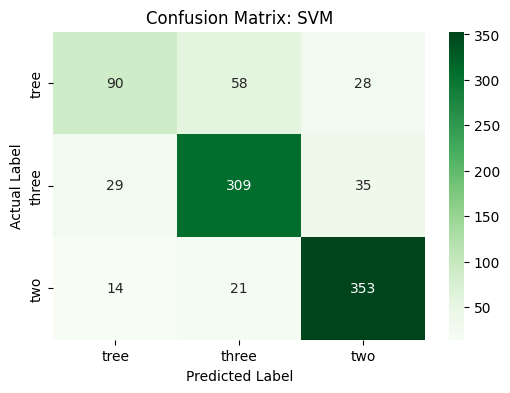

Saved to /content/drive/MyDrive/speech_commands_project/results/SVM_confusion_matrix.png


In [5]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Prints classification report and saves:
      results_path/{model_name}_classification_report.csv
      results_path/{model_name}_confusion_matrix.png
    """
    report_dict = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    report_df   = pd.DataFrame(report_dict).transpose().round(2)
    report_csv  = os.path.join(results_path, f"{model_name.replace(' ', '_')}_classification_report.csv")
    report_df.to_csv(report_csv)

    print(f"\n--- {model_name} Classification Report ---")
    print(report_df)
    print(f"Saved to {report_csv}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    heatmap_path = os.path.join(results_path, f"{model_name.replace(' ', '_')}_confusion_matrix.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved to {heatmap_path}")


evaluate_model(y_test, rf_preds,  'Random_Forest')
evaluate_model(y_test, svm_preds, 'SVM')


In [6]:
!pip install objsize

## **Engineering Metrics**
##### RF: total number of nodes across all trees (structural complexity proxy)
##### SVM: number of support vectors (determines decision boundary complexity)
#####  Metrics
    Runtime CPU (ms): total inference on full test set / N samples
    Latency (ms) : median of n_latency_runs single-sample predictions (per-call cost; robust to OS scheduling spikes)
    Model Size (KB): pickle-serialised byte size on disk (flash equivalent)
    Memory RAM (KB): RSS delta before/after model load into a fresh process(approximated here as objsize deep-object size)
    Parameters:F: total tree nodes; SVM: support vector count

In [7]:
import gc
import objsize

# parameters
def count_ml_params(model, model_name):
    """

    """
    if 'Forest' in model_name:
        return sum(t.tree_.node_count for t in model.estimators_)
    elif 'SVM' in model_name:
        return int(model.n_support_.sum())
    return 0

def get_engineering_metrics(model, X_test_flat, y_test, model_name,
                             n_warmup=5, n_latency_runs=50):


    # ── 1. Model Size (Flash / Disk) ─────────────────────────────────────────
    # Serialize with pickle and measure byte count.
    # This is the closest equivalent to 'file size on disk' for sklearn models
    # (there is no TFLite file; pickle is the standard serialisation format).
    model_bytes   = sys.getsizeof(pickle.dumps(model))
    model_size_kb = round(model_bytes / 1024, 2)

    # ── 2. Memory RAM (KB) ───────────────────────────────────────────────────
    # objsize.get_deep_size() traverses the entire Python object graph
    # (arrays, dicts, sub-objects) to give the true in-memory footprint.
    # This is different from Model Size: pickle adds serialization overhead;
    # objsize measures the live object in RAM.
    try:
        ram_kb = round(objsize.get_deep_size(model) / 1024, 2)
    except Exception:
        # Fallback: RSS delta (less precise but always works)
        gc.collect()
        proc = psutil.Process(os.getpid())
        mem_before = proc.memory_info().rss
        _ = pickle.loads(pickle.dumps(model))   # force object into memory
        gc.collect()
        mem_after = proc.memory_info().rss
        ram_kb = round(max(0, mem_after - mem_before) / 1024, 2)

    # ── 3. Warm-up (avoid cold-start JIT bias in timing) ────────────────────
    for i in range(min(n_warmup, len(X_test_flat))):
        model.predict(X_test_flat[i:i+1])

    # ── 4. Latency (ms) — median of 50 single-sample calls ──────────────────
    # Single-sample latency is the correct measure for real-time deployment.
    # Median is used (not mean) because OS scheduling occasionally causes
    # outlier spikes; median is robust to those.
    latency_times = []
    for i in range(n_latency_runs):
        idx = i % len(X_test_flat)
        t0  = time.perf_counter()
        model.predict(X_test_flat[idx:idx+1])
        latency_times.append((time.perf_counter() - t0) * 1000)
    latency_ms = round(float(np.median(latency_times)), 4)

    # ── 5. Runtime CPU (ms per sample) — full test-set throughput ───────────
    # This is NOT training time. It is: how long does it take to run
    # inference across the entire test set, divided by N.
    # Measures sustained throughput (different from single-call latency).
    t0         = time.perf_counter()
    model.predict(X_test_flat)
    runtime_ms = round(((time.perf_counter() - t0) / len(X_test_flat)) * 1000, 4)

    # ── 6. Parameter count ───────────────────────────────────────────────────
    param_count = count_ml_params(model, model_name)

    return {
        'Runtime CPU (ms)': runtime_ms,
        'Latency (ms)':     latency_ms,
        'Model Size (KB)':  model_size_kb,
        'Memory RAM (KB)':  ram_kb,
        'Parameters':       param_count,
    }


# ── Collect metrics for both models ─────────────────────────────────────────
models_info = [
    ('Random_Forest', rf_model,  rf_acc,  rf_train_time_sec),
    ('SVM',           svm_model, svm_acc, svm_train_time_sec),
]

metrics_rows     = []   # for results CSV
log_rows         = []   # for log CSV

for model_name, model, acc, train_sec in models_info:
    print(f"\n--- Measuring: {model_name} ---")

    m = get_engineering_metrics(model, X_test_flat, y_test, model_name)

    print(f"  Accuracy:          {acc:.2%}")
    print(f"  Runtime CPU:       {m['Runtime CPU (ms)']:.4f} ms/sample")
    print(f"  Latency:           {m['Latency (ms)']:.4f} ms  (median single-sample)")
    print(f"  Model Size (disk): {m['Model Size (KB)']:.2f} KB")
    print(f"  Memory RAM:        {m['Memory RAM (KB)']:.2f} KB")
    print(f"  Parameters:        {m['Parameters']:,}")

    result_row = {
        'Model':            model_name,
        'Accuracy':         round(acc, 4),
        'Runtime CPU (ms)': m['Runtime CPU (ms)'],
        'Latency (ms)':     m['Latency (ms)'],
        'Model Size (KB)':  m['Model Size (KB)'],
        'Memory RAM (KB)':  m['Memory RAM (KB)'],
        'Parameters':       m['Parameters'],
    }
    metrics_rows.append(result_row)

    log_rows.append({
        **result_row,
        'Train Time (sec)': train_sec,
        'Timestamp':        time.strftime('%Y-%m-%d %H:%M:%S')
    })


# ── Build DataFrames ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(metrics_rows)
log_df     = pd.DataFrame(log_rows)

# ── RESULTS: save to results_path ────────────────────────────────────────────
results_csv = os.path.join(results_path, 'ml_metrics_results.csv')
metrics_df.to_csv(results_csv, index=False)
print(f"\nResults saved in {results_csv}")

# ── LOG: save to log_path ────────────────────────────────────────────────────
log_csv = os.path.join(log_path, 'ml_metrics_log.csv')
log_df.to_csv(log_csv, index=False)
print(f"Log saved in {log_csv}")

print("\n── Final Metrics Table ──")
display(metrics_df)



--- Measuring: Random_Forest ---
  Accuracy:          78.76%
  Runtime CPU:       0.0666 ms/sample
  Latency:           13.7974 ms  (median single-sample)
  Model Size (disk): 14796.05 KB
  Memory RAM:        120.88 KB
  Parameters:        171,786

--- Measuring: SVM ---
  Accuracy:          80.26%
  Runtime CPU:       29.5811 ms/sample
  Latency:           13.3245 ms  (median single-sample)
  Model Size (disk): 53034.71 KB
  Memory RAM:        53036.93 KB
  Parameters:        5,293

Results saved in /content/drive/MyDrive/speech_commands_project/results/ml_metrics_results.csv
Log saved in /content/drive/MyDrive/speech_commands_project/logs/ml_metrics_log.csv

── Final Metrics Table ──


,Model,Accuracy,Runtime CPU (ms),Latency (ms),Model Size (KB),Memory RAM (KB),Parameters
0,Random_Forest,0.7876,0.0666,13.7974,14796.05,120.88,171786
1,SVM,0.8026,29.5811,13.3245,53034.71,53036.93,5293
